In [1]:
import globals as gl
import pickle

import os
import numpy as np
import sys

import PcmPy as pcm

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import rsatoolbox as rsa

import warnings
warnings.filterwarnings("ignore")

plt.close('all')
plt.style.use('default')


Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


subj102, SMA
subj103, SMA
subj104, SMA
subj106, SMA
subj107, SMA
subj102, PMd
subj103, PMd
subj104, PMd
subj106, PMd
subj107, PMd
subj102, PMv
subj103, PMv
subj104, PMv
subj106, PMv
subj107, PMv
subj102, M1
subj103, M1
subj104, M1
subj106, M1
subj107, M1
subj102, S1
subj103, S1
subj104, S1
subj106, S1
subj107, S1
subj102, SPLa
subj103, SPLa
subj104, SPLa
subj106, SPLa
subj107, SPLa
subj102, SPLp
subj103, SPLp
subj104, SPLp
subj106, SPLp
subj107, SPLp
subj102, V1
subj103, V1
subj104, V1
subj106, V1
subj107, V1


Text(0.02, 0.5, 'activation (a.u.)')

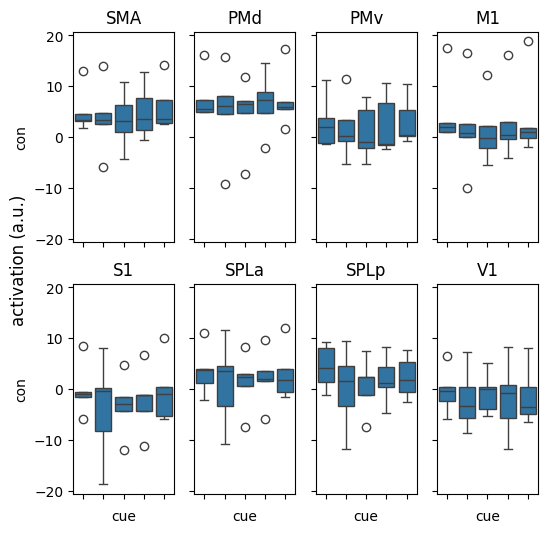

In [3]:
experiment = 'smp2'
snS = [102, 103, 104, 106, 107]
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

regressors = ['0%', '25%', '50%', '75%', '100%']

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(6, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4

    con_avg = np.zeros((len(snS), len(regressors)))

    dict_con = {
        'cue': [],
        'sn': [],
        'con': []
    }

    for s, sn in enumerate(snS):

        print(f'subj{sn}, {roi}')

        row = r // 4
        col = r % 4

        reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}',
                                       f'subj{sn}_reginfo.tsv'), sep="\t")

        con = np.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.con.npy'))

        for regr, regressor in enumerate(regressors):
            dict_con['con'].append(np.nanmean(con[reginfo.name.str.replace(" ", "").unique() == regressor]))
            dict_con['sn'].append(sn)
            dict_con['cue'].append(regressor)

    df_con = pd.DataFrame(dict_con)
    sns.boxplot(df_con, ax=axs[row, col], y='con', x='cue')

    axs[row, col].set_title(roi)
    axs[row, col].tick_params(axis='x', rotation=45)
    axs[row, col].set_xticklabels(axs[row, col].get_xticklabels(), ha='right')

fig.supylabel('activation (a.u.)')

 # **Cue representation**

## **Planning**

Text(0.5, 0.98, 'Planning, average distances across participants (N=5), hemisphere:L')

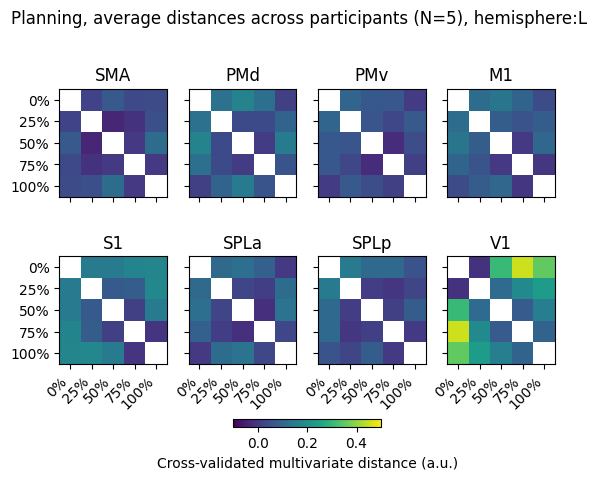

In [13]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Planning, average distances across participants (N={len(snS)}), hemisphere:{Hem}')

## **Execution**

In [ ]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, 1.5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Execution, average distances across participants (N={len(snS)}), hemisphere:{Hem}')


subj102, SMA
subj103, SMA


KeyboardInterrupt: 

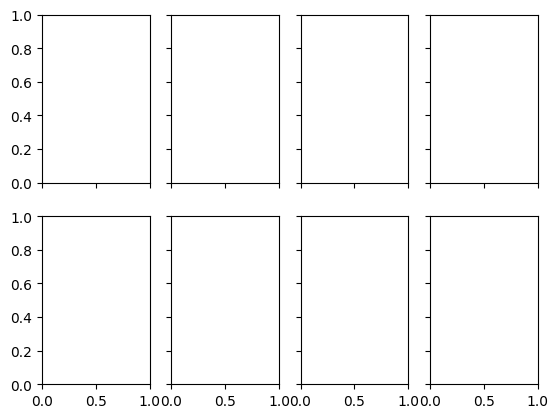

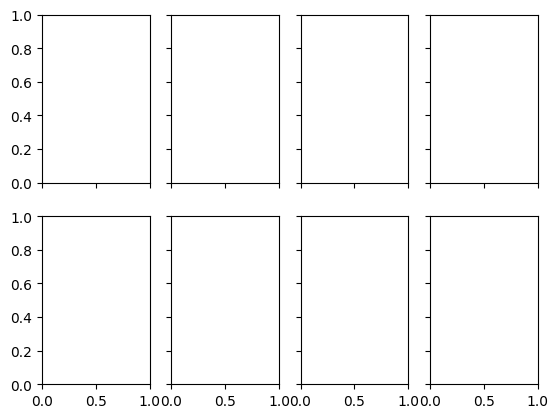

In [12]:
experiment = 'smp2'
roi = 'S1'
Hem = 'L'
glm = 12

snS = [102, 103, 104, 106, 107]

fig1, axs1 = plt.subplots(2, 4, sharex=True, sharey=True)
fig2, axs2 = plt.subplots(2, 4, sharex=True, sharey=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4

    G_est = list()
    G_hat = list()

    for sn in snS:

        print(f'subj{sn}, {roi}')

        betas = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}',
                                                         f'subj{sn}', f'ROI.{Hem}.{roi}.beta.npy'))
        res = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}',
                                   f'subj{sn}', f'ROI.{Hem}.{roi}.res.npy'))

        betas_prewhitened = betas / res

        reginfo = pd.read_csv(
                                os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}',
                                             f'subj{sn}_reginfo.tsv'), sep='\t')
        cond_vec = reginfo.name.str.replace(" ", "").map(gl.regressor_mapping)
        part_vec = reginfo.run

        idx = cond_vec.isin([0, 1, 2, 3, 4])

        G_est_tmp, _ = pcm.est_G_crossval(betas_prewhitened[idx], cond_vec[idx], part_vec[idx])
        G_est.append(G_est_tmp)

        A = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'features.plan.npy'))

        # T_in = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.plan.glm{glm}.{Hem}.{roi}.pkl'))
        T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
        # T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

        with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{Hem}.{roi}.pkl'), 'rb') as f:
            theta_in = pickle.load(f)

        with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), 'rb') as f:
            theta_cv = pickle.load(f)

        with open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.plan.glm{glm}.{Hem}.{roi}.pkl'), 'rb') as f:
            theta_gr = pickle.load(f)
        # pcm.model_plot(T_cv.likelihood, null_model='null', noise_ceiling='ceil')

        M = pcm.FeatureModel('cue', A)
        G_hat_tmp, _ = M.predict(theta_cv[1][:M.n_param, snS.index(sn)])
        G_hat.append(G_hat_tmp)

    G_est = np.stack(G_est, axis=0)
    G_hat = np.stack(G_hat, axis=0)

    axs1[row, col].imshow(G_est.mean(axis=0))
    axs2[row, col].imshow(G_hat.mean(axis=0))



roi: SMA
roi: PMd
roi: PMv
roi: M1
roi: S1
roi: SPLa
roi: SPLp
roi: V1


Text(0, 0.5, 'Log Bayes Factor')

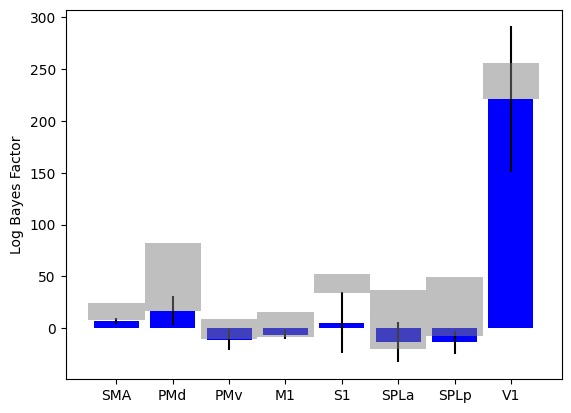

In [11]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

fig, axs = plt.subplots()

for r, roi in enumerate(rois):

    print(f'roi: {roi}')

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    likelihood = T_cv.likelihood
    baseline = likelihood.loc[:,'null'].values
    likelihood = likelihood - baseline.reshape(-1,1)

    noise_lower = likelihood.ceil.mean()
    noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()

    axs.bar(r, likelihood.cue.mean(), yerr=likelihood.cue.std() / np.sqrt(len(likelihood.cue)), color='b')

    noiserect = patches.Rectangle((r - .5, noise_lower), 1, noise_upper-noise_lower, linewidth=0, facecolor='grey', zorder=1e6, alpha=.5)
    axs.add_patch(noiserect)


axs.set_xticks(np.arange(len(rois)))
axs.set_xticklabels(rois)
axs.set_ylabel('Log Bayes Factor')